In [1]:
import sys
!{sys.executable} -m pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 63.0 MB/s eta 0:00:00:00:0100:01


In [3]:
!{sys.executable} -m pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
!{sys.executable} -m pip install h3

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00


In [1]:
import os
import glob
import hashlib
import concurrent.futures
from pathlib import Path

import pandas as pd
import numpy as np

import pyarrow as pa
import pyarrow.csv as pc
import pyarrow.compute as pac
import pyarrow.parquet as pq

from tqdm.auto import tqdm
import h3

In [2]:
data_dirs_path = "/green-projects/project-urban_colocation_intelligence/workspace/share/data"

raw_months = ("2025-03", "2025-04")

cw_csv_path = os.path.join(
    data_dirs_path,
    "locomizer_filtered_output",
    "canarywharf_r10_2025-03_04.csv"
)

output_folder = Path(data_dirs_path) / "visitor_origin_parquet"
output_folder.mkdir(parents=True, exist_ok=True)

In [4]:
cw_df = pd.read_csv(cw_csv_path)

print(cw_df.columns)

Index(['id', 'lat', 'lon', 'ts', 'date', 'gridcell', 'type'], dtype='str')


In [5]:
cw_users = set(cw_df["id"].unique())

print("Unique Canary Wharf visitors:", len(cw_users))

Unique Canary Wharf visitors: 456567


In [6]:
print("Total rows in CW dataset:", len(cw_df))
print("Unique IDs:", cw_df["id"].nunique())

Total rows in CW dataset: 4547198
Unique IDs: 456567


In [7]:
cw_visit_counts = cw_df.groupby("id").size()

active_users = cw_visit_counts[cw_visit_counts >= 2].index

print("Users with ≥2 visits:", len(active_users))

Users with ≥2 visits: 314087


In [8]:
active_users = cw_visit_counts[cw_visit_counts >= 3].index

In [9]:
print("Users with ≥3 visits:", len(active_users))

Users with ≥3 visits: 236308


In [10]:
active_users = cw_visit_counts[cw_visit_counts >= 4].index

print("Users with ≥4 visits:", len(active_users))

Users with ≥4 visits: 191340


In [11]:
active_users = cw_visit_counts[cw_visit_counts >= 5].index

print("Users with ≥5 visits:", len(active_users))

Users with ≥5 visits: 159812


**visitor threshold to filter incidental and one-time visitor noise**

In [57]:
active_users2 = cw_visit_counts[cw_visit_counts >= 2].index
print("Users with ≥2 visits:", len(active_users2))

active_users3 = cw_visit_counts[cw_visit_counts >= 3].index
print("Users with ≥3 visits:", len(active_users3))

active_users4 = cw_visit_counts[cw_visit_counts >= 4].index
print("Users with ≥4 visits:", len(active_users4))

active_users5 = cw_visit_counts[cw_visit_counts >= 5].index
print("Users with ≥5 visits:", len(active_users5))

Users with ≥2 visits: 314087
Users with ≥3 visits: 236308
Users with ≥4 visits: 191340
Users with ≥5 visits: 159812


In [12]:
active_users3 = cw_visit_counts[cw_visit_counts >= 3].index
print("Users with ≥3 visits:", len(active_users3))

active_users5 = cw_visit_counts[cw_visit_counts >= 5].index
print("Users with ≥5 visits:", len(active_users5))

Users with ≥3 visits: 236308
Users with ≥5 visits: 159812


In [15]:
# =============================
# USER-BASED FULL STOP FILTER
# =============================

_USER_VALUESET = None
_BLOCK_SIZE = None
_OUT_DIR = None

_COL_NAMES = ["id", "lat", "lon", "ts", "date", "gridcell", "type"]


def _init_worker(user_list, out_dir_str, block_size):
    global _USER_VALUESET, _OUT_DIR, _BLOCK_SIZE
    _USER_VALUESET = pa.array(list(user_list), type=pa.string())
    _OUT_DIR = Path(out_dir_str)
    _BLOCK_SIZE = int(block_size)


def _process_one_file_user(file_path: str):

    global _USER_VALUESET, _OUT_DIR, _BLOCK_SIZE

    h = hashlib.md5(file_path.encode("utf-8")).hexdigest()
    out_path = _OUT_DIR / f"part-{h}.parquet"

    if out_path.exists() and out_path.stat().st_size > 0:
        return str(out_path)

    read_opts = pc.ReadOptions(
        column_names=_COL_NAMES,
        block_size=_BLOCK_SIZE,
        use_threads=True
    )

    parse_opts = pc.ParseOptions(delimiter="\t")
    conv_opts  = pc.ConvertOptions(strings_can_be_null=False)

    try:
        reader = pc.open_csv(
            file_path,
            read_options=read_opts,
            parse_options=parse_opts,
            convert_options=conv_opts,
        )

        kept_batches = []

        for batch in reader:
            uid = batch.column(batch.schema.get_field_index("id"))
            tm  = batch.column(batch.schema.get_field_index("type"))

            mask = pac.and_(
                pac.equal(tm, "stop"),
                pac.is_in(uid, value_set=_USER_VALUESET),
            )

            if pac.any(mask).as_py():
                kept_batches.append(batch.filter(mask))

        if not kept_batches:
            return None

        table = pa.Table.from_batches(kept_batches)

        for col, t in [("lat", pa.float64()), ("lon", pa.float64()), ("ts", pa.float64())]:
            idx = table.schema.get_field_index(col)
            table = table.set_column(idx, col, pac.cast(table.column(col), t, safe=False))

        pq.write_table(table, out_path)
        return str(out_path)

    except Exception as e:
        print("Error:", file_path, e)
        return None


def filter_users_full_stops(
    *,
    user_list,
    months,
    max_workers=6,
    block_size=(1 << 26),
):

    files = []
    for m in months:
        files.extend(
            glob.glob(os.path.join(data_dirs_path, m, "**", "*.gz"), recursive=True)
        )

    print("Found raw files:", len(files))

    written = []

    with concurrent.futures.ProcessPoolExecutor(
        max_workers=max_workers,
        initializer=_init_worker,
        initargs=(list(user_list), str(output_folder), int(block_size)),
    ) as ex:

        futures = [ex.submit(_process_one_file_user, fp) for fp in files]

        for fut in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            result = fut.result()
            if result:
                written.append(result)

    print("Parquet parts written:", len(written))

    part_files = list(output_folder.glob("part-*.parquet"))
    if not part_files:
        print("No matches.")
        return None

    table = pq.read_table(output_folder)
    df = table.to_pandas()

    print("Total rows:", len(df))
    return df


In [16]:
import os
print(os.cpu_count())

64


In [17]:
cw_users = set(active_users3)

full_stops_df = filter_users_full_stops(
    user_list=cw_users,
    months=raw_months,
    max_workers=12,
)

Found raw files: 1837


  0%|          | 0/1837 [00:00<?, ?it/s]

Parquet parts written: 1837
Total rows: 37003930


In [18]:
full_stops_df["datetime"] = pd.to_datetime(full_stops_df["ts"], unit="s")
full_stops_df["hour"] = full_stops_df["datetime"].dt.hour

night_df = full_stops_df[
    (full_stops_df["hour"] >= 19) | (full_stops_df["hour"] < 7)
].copy()

print("Night rows:", len(night_df))
print("Night unique users:", night_df["id"].nunique())

Night rows: 18043343
Night unique users: 213128


In [20]:
night_df["home_h3"] = [
    h3.latlng_to_cell(lat, lon, 9)
    for lat, lon in zip(night_df["lat"].values, night_df["lon"].values)
]

In [21]:
print(night_df["home_h3"].nunique())

78082


In [22]:
home_counts = (
    night_df
    .groupby(["id", "home_h3"])
    .size()
    .reset_index(name="count")
)

home_counts = home_counts.sort_values(
    ["id", "count"],
    ascending=[True, False]
)

home_locations = home_counts.drop_duplicates("id")

print("Users with dominant night cell:", len(home_locations))

Users with dominant night cell: 213128


In [23]:
night_totals = (
    night_df.groupby("id")
    .size()
    .reset_index(name="total_night")
)

home_locations = home_locations.merge(night_totals, on="id")

home_locations["share"] = (
    home_locations["count"] /
    home_locations["total_night"]
)

stable_homes = home_locations[
    home_locations["share"] >= 0.4
]

print("Stable inferred homes:", len(stable_homes))

Stable inferred homes: 185049


In [24]:
origin_counts = (
    stable_homes
    .groupby("home_h3")
    .size()
    .reset_index(name="visitor_count")
)

print("Number of origin cells:", len(origin_counts))
origin_counts.head()

Number of origin cells: 32962


,home_h3,visitor_count
0,8909a44ce6fffff,1
1,89182d20a8bffff,1
2,89182d20dafffff,1
3,89182d2c50fffff,1
4,89182d2f53bffff,3


In [26]:
stable_homes.to_parquet("stable_homes.parquet")

In [27]:
import sys
!{sys.executable} -m pip install --upgrade geopandas shapely pyproj fiona

Defaulting to user installation because normal site-packages is not writeable
  Using cached geopandas-1.1.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (6.8 kB)
  Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached fiona-1.10.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (56 kB)
  Using cached pyogrio-0.12.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.9 kB)
Using cached geopandas-1.1.2-py3-none-any.whl (341 kB)
Using cached shapely-2.1.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.1 MB)
Using cached pyproj-3.7.2-cp312-cp312-manylinux_2_28_x86_64.whl (9.6 MB)
Using cached fiona-1.10.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.2 MB)
Using cached pyogrio-0.12.1-cp312-cp312-manylinux_2_28_x86_64.whl (32.5 MB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning

In [28]:
import geopandas as gpd
print(gpd.__version__)


1.1.2


In [29]:
import pandas as pd
stable_homes = pd.read_parquet("stable_homes.parquet")

In [30]:
origin_counts = (
    stable_homes
    .groupby("home_h3")
    .size()
    .reset_index(name="visitor_count")
)

print("Number of origin cells:", len(origin_counts))
origin_counts.head()

Number of origin cells: 32962


,home_h3,visitor_count
0,8909a44ce6fffff,1
1,89182d20a8bffff,1
2,89182d20dafffff,1
3,89182d2c50fffff,1
4,89182d2f53bffff,3


In [31]:
from shapely.geometry import Polygon

def h3_to_polygon(h):
    boundary = h3.cell_to_boundary(h)
    return Polygon([(lng, lat) for lat, lng in boundary])

origin_counts["geometry"] = origin_counts["home_h3"].apply(h3_to_polygon)

origin_gdf = gpd.GeoDataFrame(
    origin_counts,
    geometry="geometry",
    crs="EPSG:4326"
)

origin_gdf.head()


,home_h3,visitor_count,geometry
0,8909a44ce6fffff,1,"POLYGON ((-1.27354 60.13651, -1.27602 60.13568..."
1,89182d20a8bffff,1,"POLYGON ((-5.04807 52.00239, -5.05017 52.00131..."
2,89182d20dafffff,1,"POLYGON ((-4.9723 51.99795, -4.9744 51.99687, ..."
3,89182d2c50fffff,1,"POLYGON ((-5.09428 51.9146, -5.09638 51.91352,..."
4,89182d2f53bffff,3,"POLYGON ((-5.12699 51.96595, -5.12909 51.96486..."


(51.2, 51.8)

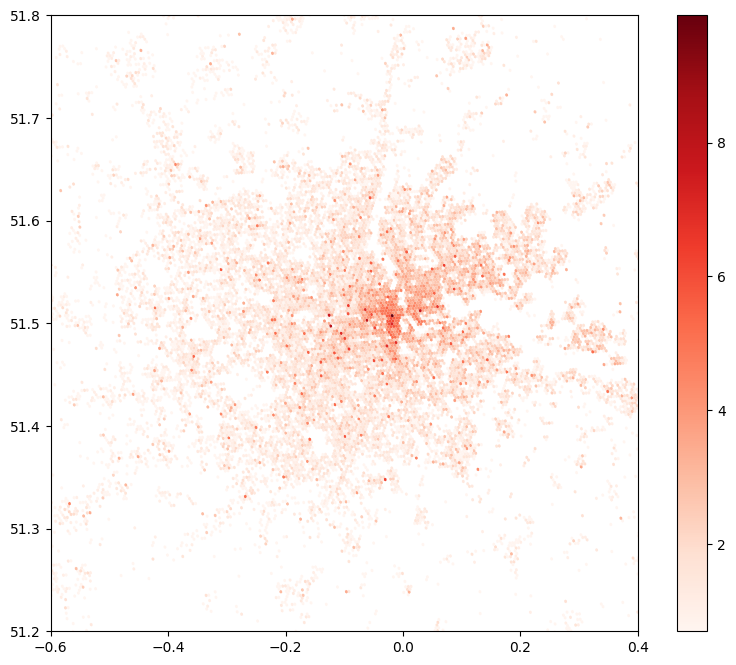

In [34]:
import numpy as np

origin_gdf["log_visitors"] = np.log1p(origin_gdf["visitor_count"])

ax = origin_gdf.plot(
    column="log_visitors",
    cmap="Reds",
    legend=True,
    figsize=(10,8),
    linewidth=0
)

ax.set_xlim(-0.6, 0.4)
ax.set_ylim(51.2, 51.8)


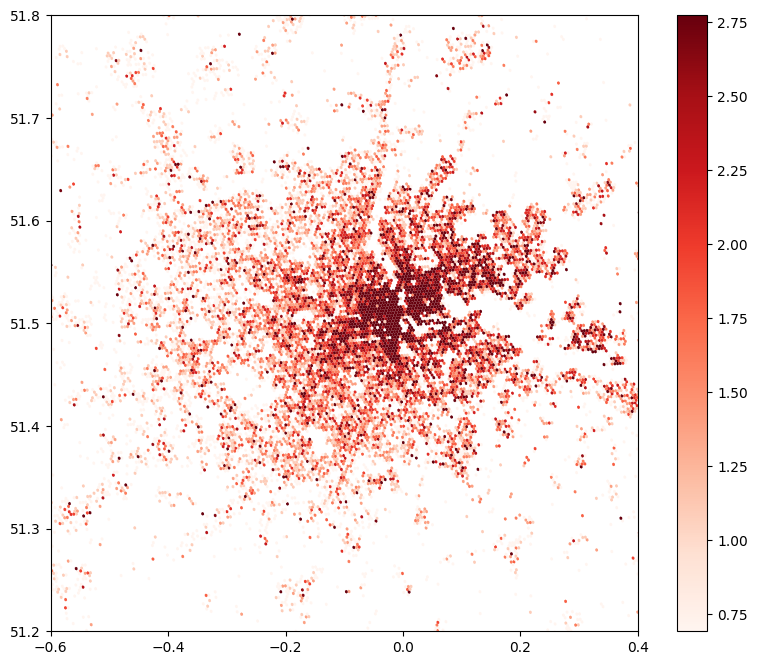

In [36]:
origin_gdf["log_visitors"] = np.log1p(origin_gdf["visitor_count"])

vmin = origin_gdf["log_visitors"].quantile(0.05)
vmax = origin_gdf["log_visitors"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

origin_gdf.plot(
    column="log_visitors",
    cmap="Reds",
    legend=True,
    linewidth=0,
    vmin=vmin,
    vmax=vmax,
    ax=ax
)

ax.set_xlim(-0.6, 0.4)
ax.set_ylim(51.2, 51.8)

plt.show()


In [38]:
cw_csv_path = "/green-projects/project-urban_colocation_intelligence/workspace/share/data/locomizer_filtered_output/canarywharf_r10_2025-03_04.csv"


In [43]:
origin_gdf["intensity"] = origin_gdf["log_visitors"]

# Calculate percentile thresholds
p50 = origin_gdf["intensity"].quantile(0.50)
p75 = origin_gdf["intensity"].quantile(0.75)
p90 = origin_gdf["intensity"].quantile(0.90)

print("Thresholds:")
print("50th percentile:", round(p50, 3))
print("75th percentile:", round(p75, 3))
print("90th percentile:", round(p90, 3))


Thresholds:
50th percentile: 0.693
75th percentile: 1.386
90th percentile: 2.197


In [44]:
def classify_intensity(x):
    if x >= p90:
        return "Strong concentration"
    elif x >= p75:
        return "Secondary concentration"
    elif x >= p50:
        return "Moderate concentration"
    else:
        return "Weak concentration"

origin_gdf["origin_class"] = origin_gdf["intensity"].apply(classify_intensity)


In [45]:
summary_table = (
    origin_gdf
    .groupby("origin_class")
    .agg(
        origin_cells=("home_h3", "count"),
        total_visitors=("visitor_count", "sum")
    )
    .reset_index()
    .sort_values("total_visitors", ascending=False)
)

summary_table


,origin_class,origin_cells,total_visitors
2,Strong concentration,3527,130526
0,Moderate concentration,23356,28113
1,Secondary concentration,6079,26410


In [46]:
total_visitors = summary_table["total_visitors"].sum()

summary_table["visitor_share_%"] = (
    summary_table["total_visitors"] / total_visitors * 100
).round(2)

summary_table


,origin_class,origin_cells,total_visitors,visitor_share_%
2,Strong concentration,3527,130526,70.54
0,Moderate concentration,23356,28113,15.19
1,Secondary concentration,6079,26410,14.27


In [47]:
lb_folder = Path("/green-projects/project-urban_colocation_intelligence/workspace/share/data/boundary/London_LSOA_2021/origdata/LB_shp")

# Get all shapefiles
shp_files = list(lb_folder.glob("*.shp"))

print("Number of borough shapefiles:", len(shp_files))

# Read and merge
boroughs = gpd.GeoDataFrame(
    pd.concat([gpd.read_file(shp) for shp in shp_files], ignore_index=True)
)

boroughs = boroughs.to_crs("EPSG:4326")

boroughs.head()


Number of borough shapefiles: 33


,lsoa21cd,lsoa21nm,msoa21cd,msoa21nm,lad22cd,lad22nm,geometry
0,E01003912,Southwark 019A,E02000825,Southwark 019,E09000028,Southwark,"POLYGON ((-0.07948 51.47656, -0.0794 51.47651,..."
1,E01003923,Southwark 017A,E02000823,Southwark 017,E09000028,Southwark,"POLYGON ((-0.09539 51.48076, -0.09553 51.48072..."
2,E01003924,Southwark 021E,E02000827,Southwark 021,E09000028,Southwark,"POLYGON ((-0.09436 51.48055, -0.09435 51.48043..."
3,E01003925,Southwark 020E,E02000826,Southwark 020,E09000028,Southwark,"POLYGON ((-0.087 51.47841, -0.08712 51.47838, ..."
4,E01003926,Southwark 021F,E02000827,Southwark 021,E09000028,Southwark,"POLYGON ((-0.10019 51.48032, -0.1001 51.48031,..."


In [48]:
# Spatial join
origin_with_borough = gpd.sjoin(
    origin_gdf,
    boroughs[["lad22nm", "geometry"]],
    how="left",
    predicate="intersects"
)

origin_with_borough.head()


,home_h3,visitor_count,geometry,log_visitors,is_cw_resident,intensity,origin_class,index_right,lad22nm
0,8909a44ce6fffff,1,"POLYGON ((-1.27354 60.13651, -1.27602 60.13568...",0.693147,False,0.693147,Moderate concentration,NaN,NaN
1,89182d20a8bffff,1,"POLYGON ((-5.04807 52.00239, -5.05017 52.00131...",0.693147,False,0.693147,Moderate concentration,NaN,NaN
2,89182d20dafffff,1,"POLYGON ((-4.9723 51.99795, -4.9744 51.99687, ...",0.693147,False,0.693147,Moderate concentration,NaN,NaN
3,89182d2c50fffff,1,"POLYGON ((-5.09428 51.9146, -5.09638 51.91352,...",0.693147,False,0.693147,Moderate concentration,NaN,NaN
4,89182d2f53bffff,3,"POLYGON ((-5.12699 51.96595, -5.12909 51.96486...",1.386294,False,1.386294,Secondary concentration,NaN,NaN


In [49]:
borough_summary = (
    origin_with_borough
    .groupby("lad22nm")
    .agg(
        total_visitors=("visitor_count", "sum"),
        origin_cells=("home_h3", "count")
    )
    .reset_index()
    .sort_values("total_visitors", ascending=False)
)

borough_summary["visitor_share_%"] = (
    borough_summary["total_visitors"] /
    borough_summary["total_visitors"].sum() * 100
).round(2)

borough_summary.head(15)


,lad22nm,total_visitors,origin_cells,visitor_share_%
29,Tower Hamlets,138525,917,31.38
24,Newham,39937,1195,9.05
27,Southwark,30380,1054,6.88
10,Greenwich,21314,1255,4.83
21,Lambeth,19627,1092,4.45
22,Lewisham,18096,1164,4.10
25,Redbridge,13915,1312,3.15
0,Barking and Dagenham,13312,844,3.02
32,Westminster,11963,719,2.71
30,Waltham Forest,10860,999,2.46


In [50]:
borough_summary

,lad22nm,total_visitors,origin_cells,visitor_share_%
29,Tower Hamlets,138525,917,31.38
24,Newham,39937,1195,9.05
27,Southwark,30380,1054,6.88
10,Greenwich,21314,1255,4.83
21,Lambeth,19627,1092,4.45
22,Lewisham,18096,1164,4.10
25,Redbridge,13915,1312,3.15
0,Barking and Dagenham,13312,844,3.02
32,Westminster,11963,719,2.71
30,Waltham Forest,10860,999,2.46


In [54]:
borough_summary.tail(15)

,lad22nm,total_visitors,origin_cells,visitor_share_%
9,Enfield,5294,1137,1.20
1,Barnet,5241,1391,1.19
13,Haringey,5176,894,1.17
12,Hammersmith and Fulham,4950,577,1.12
5,Camden,4828,722,1.09
23,Merton,4157,795,0.94
19,Kensington and Chelsea,4142,520,0.94
8,Ealing,3916,1106,0.89
17,Hounslow,3602,940,0.82
28,Sutton,3353,823,0.76


**Weekday vs weekend analysis**

In [98]:
CW_users = set(active_users3)

full_stops_df = filter_users_full_stops(
    user_list=CW_users,
    months=raw_months,
    max_workers=12
)

Found raw files: 1837


  0%|          | 0/1837 [00:00<?, ?it/s]

Parquet parts written: 1837
Total rows: 37003930


In [99]:
full_stops_df["datetime"] = pd.to_datetime(
    full_stops_df["ts"],
    unit="s",
    utc=True
).dt.tz_convert("Europe/London")

full_stops_df["hour"] = full_stops_df["datetime"].dt.hour

In [100]:
full_stops_df["ts"].head()
full_stops_df["ts"].min()
full_stops_df["ts"].max()

np.float64(1746053863.0)

In [101]:
full_stops_df["datetime"].min()
full_stops_df["datetime"].max()
full_stops_df["datetime"].head()

0   2025-03-21 07:41:50+00:00
1   2025-03-21 21:01:40+00:00
2   2025-03-22 16:52:12+00:00
3   2025-03-22 22:21:26+00:00
4   2025-03-20 03:52:08+00:00
Name: datetime, dtype: datetime64[s, Europe/London]

In [102]:
# Day of week (0=Mon, 6=Sun)
full_stops_df["day_of_week"] = full_stops_df["datetime"].dt.dayofweek

# Weekend flag
full_stops_df["is_weekend"] = full_stops_df["day_of_week"] >= 5

In [103]:
full_stops_df["is_weekend"].value_counts(normalize=True) * 100

is_weekend
False    67.548812
True     32.451188
Name: proportion, dtype: float64

In [104]:
user_pattern = (
    full_stops_df
    .groupby("id")
    .agg(
        weekend_ratio=("is_weekend", "mean"),
        avg_hour=("hour", "mean"),
        total_visits=("id", "count")
    )
    .reset_index()
)

In [105]:
def classify_user(row):
    if row["weekend_ratio"] < 0.3 and 8 <= row["avg_hour"] <= 18:
        return "Likely Worker"
    elif row["weekend_ratio"] > 0.6:
        return "Likely Leisure"
    else:
        return "Mixed"

user_pattern["visitor_type"] = user_pattern.apply(classify_user, axis=1)

In [106]:
user_pattern = user_pattern.merge(
    stable_homes[["id", "home_h3"]],
    on="id",
    how="left"
)

In [107]:
visitor_with_borough = user_pattern.merge(
    origin_with_borough[["home_h3", "lad22nm"]],
    on="home_h3",
    how="left"
)

In [108]:
borough_weekend_summary = (
    visitor_with_borough
    .groupby(["lad22nm", "visitor_type"])
    .size()
    .reset_index(name="count")
)

In [109]:
borough_weekend_summary["percentage"] = (
    borough_weekend_summary
    .groupby("lad22nm")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

In [110]:
borough_worker_share = (
    borough_weekend_summary[
        borough_weekend_summary["visitor_type"] == "Likely Worker"
    ]
    .sort_values("percentage", ascending=False)
)

borough_worker_share.head(15)

,lad22nm,visitor_type,count,percentage
52,Hounslow,Likely Worker,1692,46.973903
13,Bromley,Likely Worker,3545,46.436992
70,Merton,Likely Worker,1912,45.994708
43,Harrow,Likely Worker,1300,45.887752
31,Greenwich,Likely Worker,9714,45.575678
28,Enfield,Likely Worker,2407,45.466566
16,Camden,Likely Worker,2192,45.401823
25,Ealing,Likely Worker,1761,44.969356
79,Richmond upon Thames,Likely Worker,1189,44.716059
49,Hillingdon,Likely Worker,1317,44.493243


In [111]:
borough_worker_share.head(33)

,lad22nm,visitor_type,count,percentage
52,Hounslow,Likely Worker,1692,46.973903
13,Bromley,Likely Worker,3545,46.436992
70,Merton,Likely Worker,1912,45.994708
43,Harrow,Likely Worker,1300,45.887752
31,Greenwich,Likely Worker,9714,45.575678
28,Enfield,Likely Worker,2407,45.466566
16,Camden,Likely Worker,2192,45.401823
25,Ealing,Likely Worker,1761,44.969356
79,Richmond upon Thames,Likely Worker,1189,44.716059
49,Hillingdon,Likely Worker,1317,44.493243


In [112]:
borough_leisure_share = (
    borough_weekend_summary[
        borough_weekend_summary["visitor_type"] == "Likely Leisure"
    ]
    .sort_values("percentage", ascending=False)
)

borough_leisure_share.head(15)

,lad22nm,visitor_type,count,percentage
87,Tower Hamlets,Likely Leisure,26744,19.306262
18,City of London,Likely Leisure,507,18.296644
81,Southwark,Likely Leisure,5066,16.675444
57,Kensington and Chelsea,Likely Leisure,611,14.751328
96,Westminster,Likely Leisure,1742,14.561565
63,Lambeth,Likely Leisure,2818,14.357772
36,Hammersmith and Fulham,Likely Leisure,700,14.141414
33,Hackney,Likely Leisure,1430,13.672435
9,Brent,Likely Leisure,762,13.231464
66,Lewisham,Likely Leisure,2340,12.931034


In [113]:
borough_leisure_share.head(33)

,lad22nm,visitor_type,count,percentage
87,Tower Hamlets,Likely Leisure,26744,19.306262
18,City of London,Likely Leisure,507,18.296644
81,Southwark,Likely Leisure,5066,16.675444
57,Kensington and Chelsea,Likely Leisure,611,14.751328
96,Westminster,Likely Leisure,1742,14.561565
63,Lambeth,Likely Leisure,2818,14.357772
36,Hammersmith and Fulham,Likely Leisure,700,14.141414
33,Hackney,Likely Leisure,1430,13.672435
9,Brent,Likely Leisure,762,13.231464
66,Lewisham,Likely Leisure,2340,12.931034


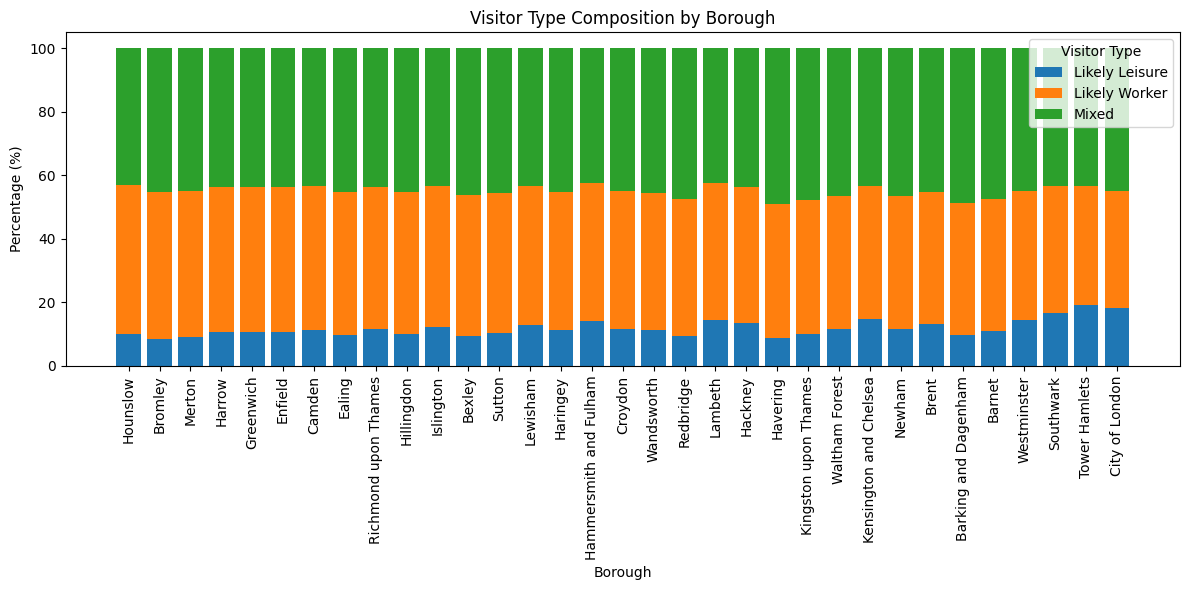

In [115]:
import matplotlib.pyplot as plt

# Pivot table
pivot_df = borough_weekend_summary.pivot(
    index="lad22nm",
    columns="visitor_type",
    values="percentage"
).fillna(0)

# Sort by worker percentage
pivot_df = pivot_df.sort_values("Likely Worker", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12,6))

bottom = None
for col in pivot_df.columns:
    if bottom is None:
        ax.bar(pivot_df.index, pivot_df[col], label=col)
        bottom = pivot_df[col]
    else:
        ax.bar(pivot_df.index, pivot_df[col], bottom=bottom, label=col)
        bottom += pivot_df[col]

ax.set_title("Visitor Type Composition by Borough")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Borough")
ax.legend(title="Visitor Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

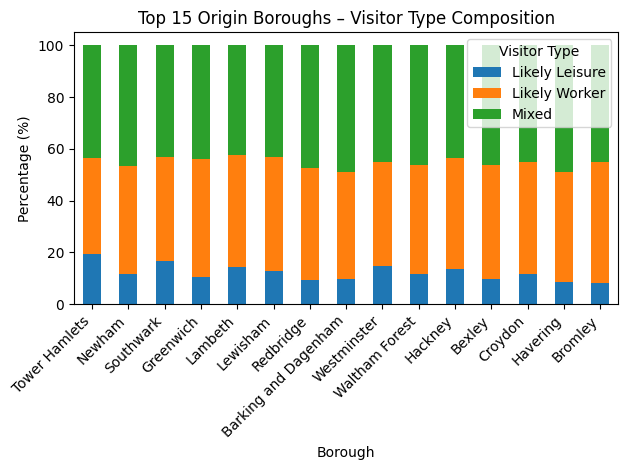

In [116]:
# Identify top 15 boroughs by total visitors
top_boroughs = (
    borough_weekend_summary
    .groupby("lad22nm")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

pivot_top = pivot_df.loc[top_boroughs]

plt.figure(figsize=(10,6))
pivot_top.plot(kind="bar", stacked=True)

plt.title("Top 15 Origin Boroughs – Visitor Type Composition")
plt.ylabel("Percentage (%)")
plt.xlabel("Borough")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Visitor Type")
plt.tight_layout()
plt.show()

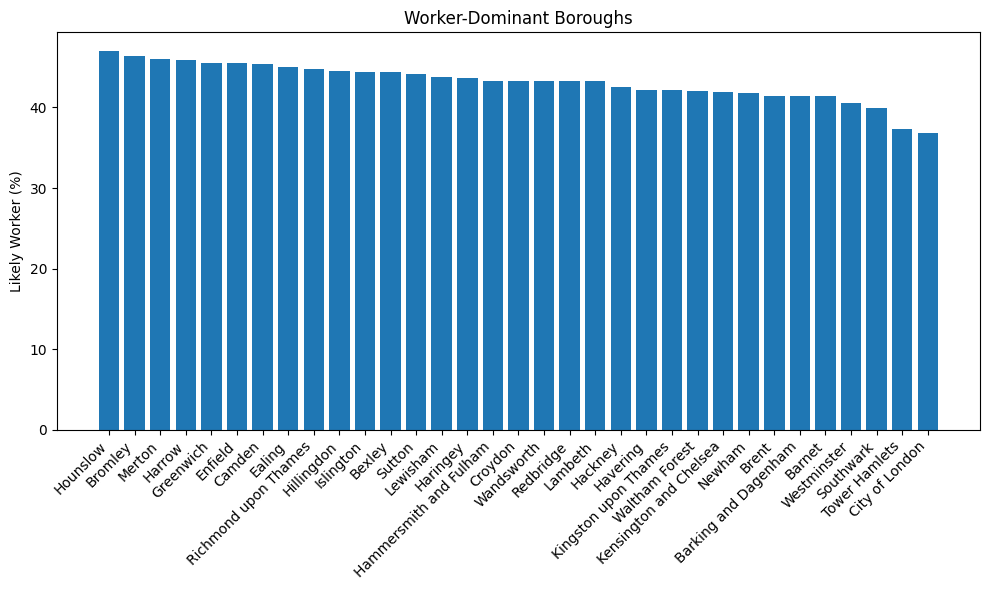

In [117]:
worker_only = borough_worker_share.sort_values("percentage", ascending=False)

plt.figure(figsize=(10,6))
plt.bar(worker_only["lad22nm"], worker_only["percentage"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Likely Worker (%)")
plt.title("Worker-Dominant Boroughs")
plt.tight_layout()
plt.show()

In [118]:
worker_df = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Likely Worker"
].sort_values("percentage", ascending=False)

leisure_df = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Likely Leisure"
].sort_values("percentage", ascending=False)

mixed_df = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Mixed"
].sort_values("percentage", ascending=False)

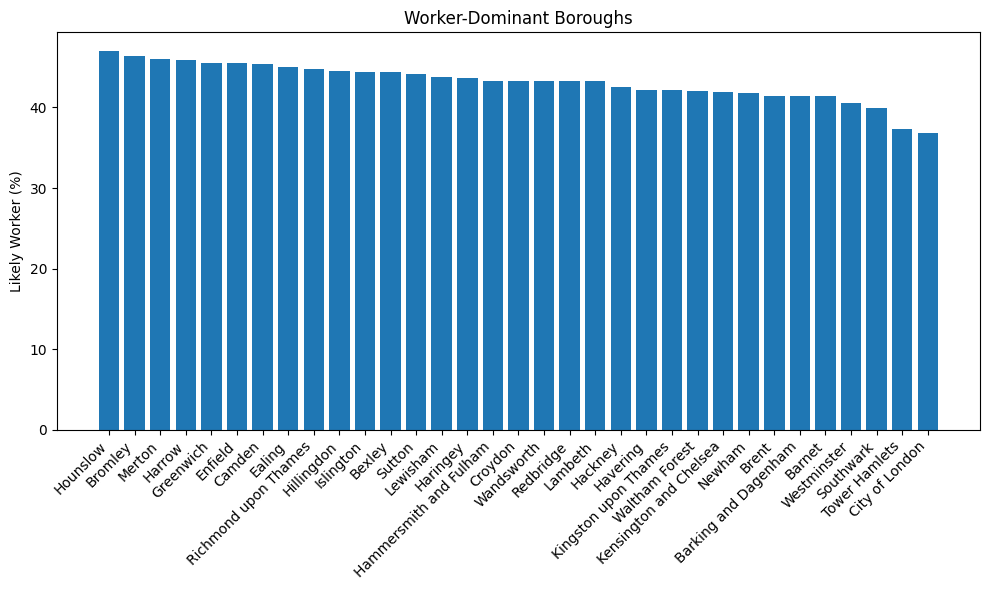

In [119]:
plt.figure(figsize=(10,6))
plt.bar(worker_df["lad22nm"], worker_df["percentage"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Likely Worker (%)")
plt.title("Worker-Dominant Boroughs")
plt.tight_layout()
plt.show()

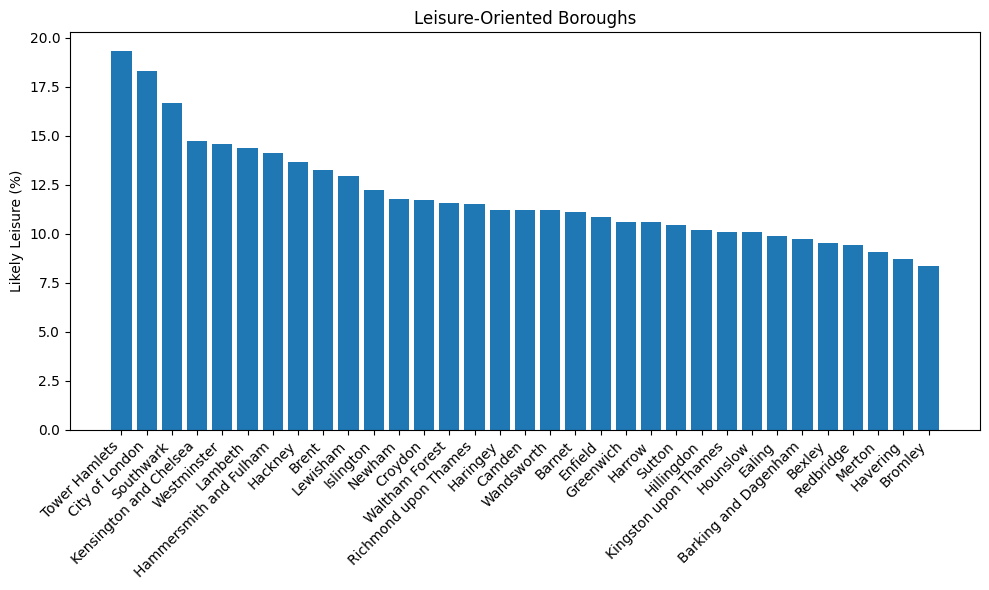

In [120]:
plt.figure(figsize=(10,6))
plt.bar(leisure_df["lad22nm"], leisure_df["percentage"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Likely Leisure (%)")
plt.title("Leisure-Oriented Boroughs")
plt.tight_layout()
plt.show()

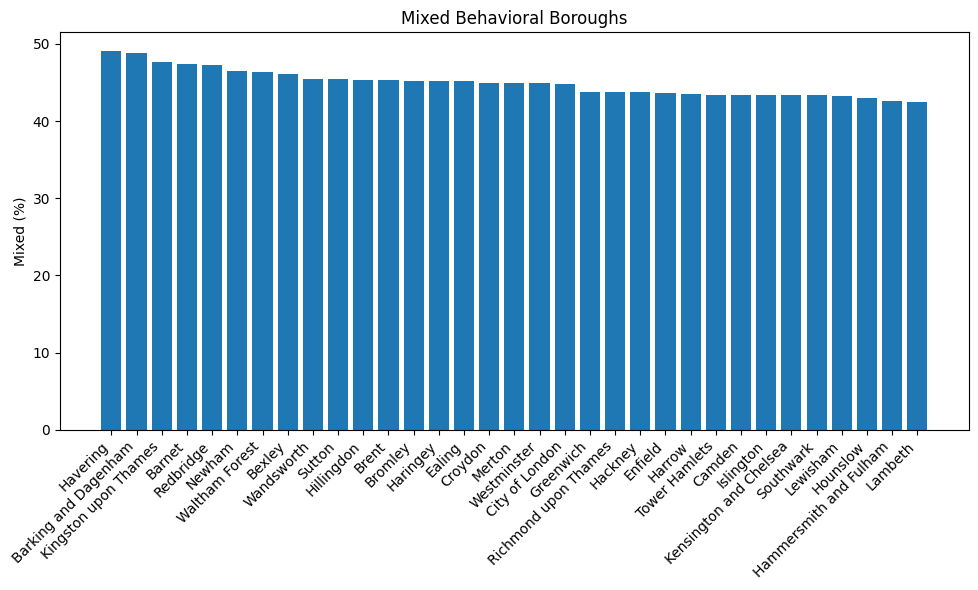

In [121]:
plt.figure(figsize=(10,6))
plt.bar(mixed_df["lad22nm"], mixed_df["percentage"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mixed (%)")
plt.title("Mixed Behavioral Boroughs")
plt.tight_layout()
plt.show()

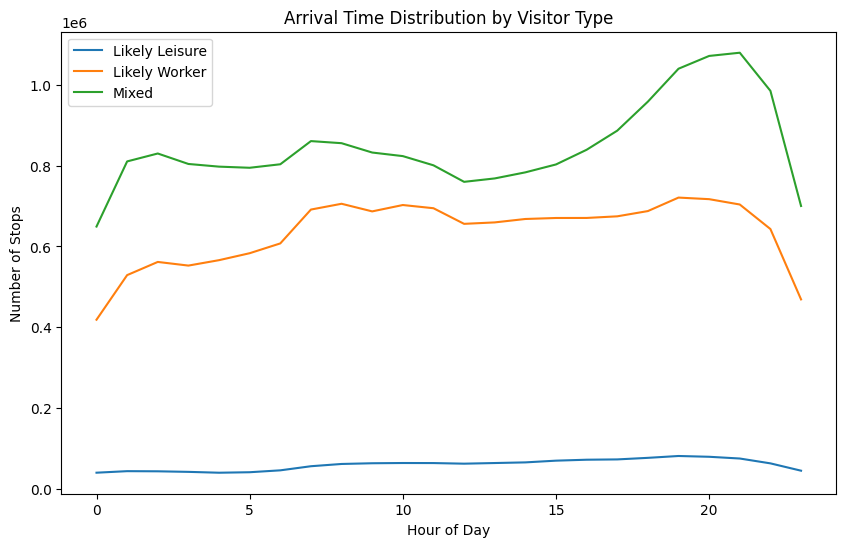

In [122]:
merged_df = full_stops_df.merge(
    user_pattern[["id", "visitor_type"]],
    on="id"
)

hour_dist = (
    merged_df
    .groupby(["visitor_type", "hour"])
    .size()
    .reset_index(name="count")
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for vt in hour_dist["visitor_type"].unique():
    subset = hour_dist[hour_dist["visitor_type"] == vt]
    plt.plot(subset["hour"], subset["count"], label=vt)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Stops")
plt.title("Arrival Time Distribution by Visitor Type")
plt.legend()
plt.show()

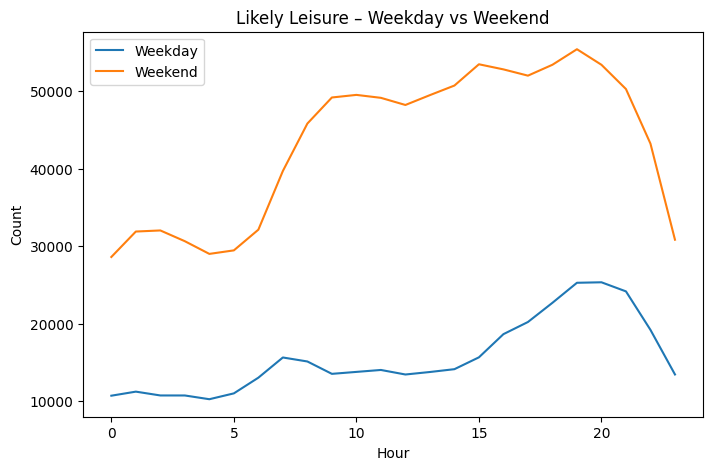

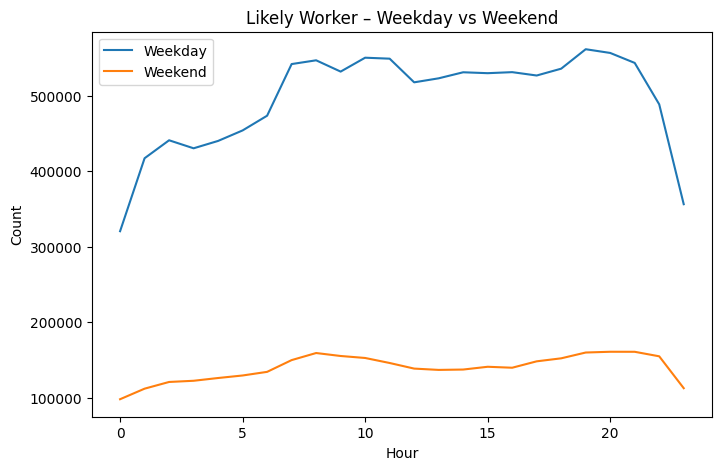

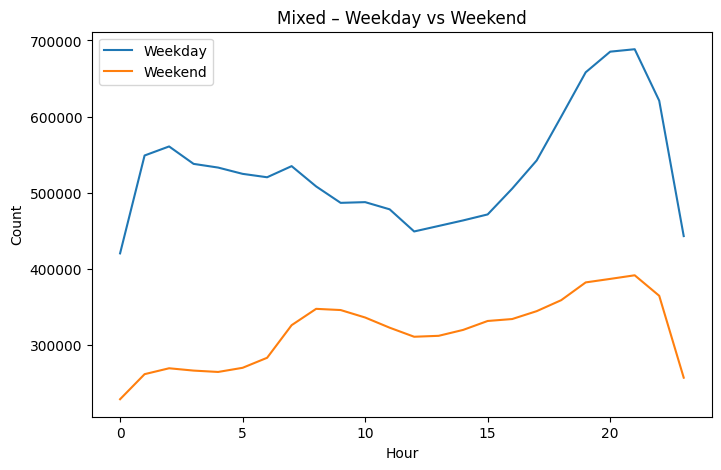

In [127]:
merged_df["is_weekend"] = merged_df["datetime"].dt.weekday >= 5

hour_daytype = (
    merged_df
    .groupby(["visitor_type", "is_weekend", "hour"])
    .size()
    .reset_index(name="count")
)

import matplotlib.pyplot as plt

for vt in hour_daytype["visitor_type"].unique():
    plt.figure(figsize=(8,5))
    
    for weekend_flag in [False, True]:
        subset = hour_daytype[
            (hour_daytype["visitor_type"] == vt) &
            (hour_daytype["is_weekend"] == weekend_flag)
        ]
        
        label = "Weekend" if weekend_flag else "Weekday"
        plt.plot(subset["hour"], subset["count"], label=label)
    
    plt.title(f"{vt} – Weekday vs Weekend")
    plt.xlabel("Hour")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [124]:
peak_hours = (
    hour_daytype
    .loc[hour_daytype.groupby(["visitor_type", "is_weekend"])["count"].idxmax()]
)

In [125]:
peak_hours

,visitor_type,is_weekend,hour,count
20,Likely Leisure,False,20,25334
43,Likely Leisure,True,19,55427
67,Likely Worker,False,19,561289
92,Likely Worker,True,20,160847
117,Mixed,False,21,688490
141,Mixed,True,21,391654


In [130]:
full_stops_df.columns

Index(['id', 'lat', 'lon', 'ts', 'date', 'gridcell', 'type', 'datetime',
       'hour', 'day_of_week', 'is_weekend'],
      dtype='str')

In [131]:
full_stops_df = full_stops_df.merge(
    user_pattern[["id", "visitor_type"]],
    on="id",
    how="left"
)

In [132]:
full_stops_df.columns

Index(['id', 'lat', 'lon', 'ts', 'date', 'gridcell', 'type', 'datetime',
       'hour', 'day_of_week', 'is_weekend', 'visitor_type'],
      dtype='str')

In [135]:
full_stops_df["ts"] = pd.to_datetime(full_stops_df["ts"], errors="coerce")

In [136]:
full_stops_df["ts"].dtype

dtype('<M8[ns]')

In [137]:
# Create date column
full_stops_df["date"] = full_stops_df["ts"].dt.date

# Remove duplicate user-hour per day
dedup_hour = full_stops_df.drop_duplicates(
    subset=["id", "date", "hour"]
)

In [138]:
hour_presence = (
    dedup_hour
    .groupby(["visitor_type", "is_weekend", "hour"])["id"]
    .nunique()
    .reset_index(name="unique_users")
)

In [139]:
hour_presence.head()

,visitor_type,is_weekend,hour,unique_users
0,Likely Leisure,False,0,2224
1,Likely Leisure,False,1,2456
2,Likely Leisure,False,2,2515
3,Likely Leisure,False,3,2600
4,Likely Leisure,False,4,2561


In [140]:
hour_presence.groupby("visitor_type")["unique_users"].sum()

visitor_type
Likely Leisure     290361
Likely Worker     1407992
Mixed             1585703
Name: unique_users, dtype: int64

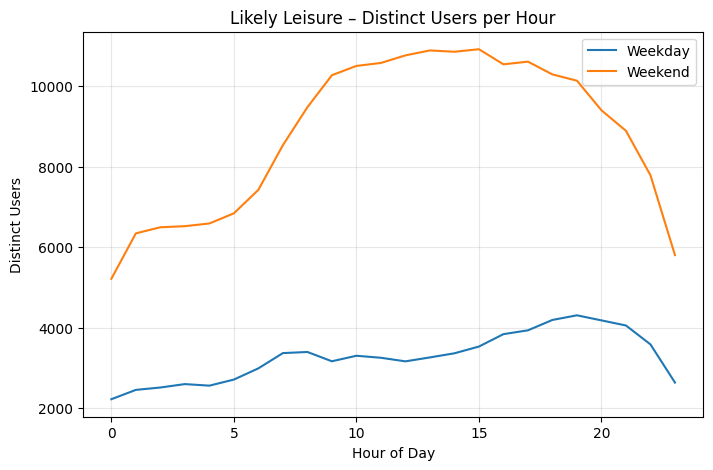

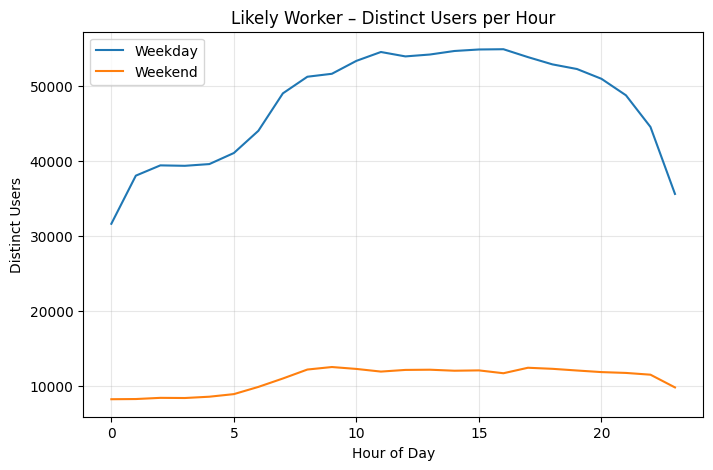

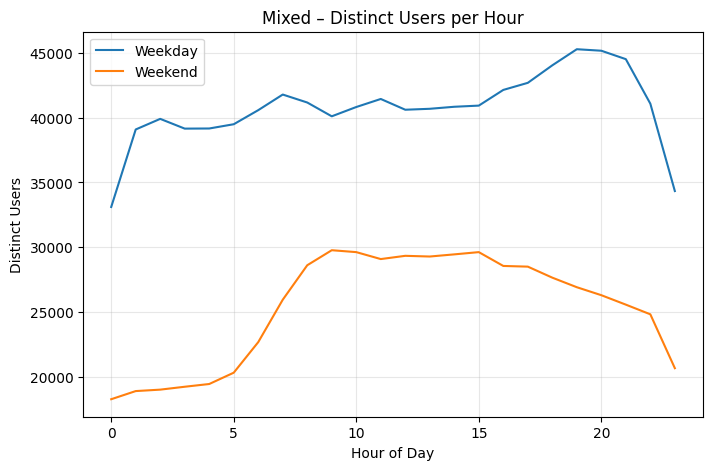

In [141]:


for vtype in hour_presence["visitor_type"].unique():
    subset = hour_presence[hour_presence["visitor_type"] == vtype]

    weekday = subset[subset["is_weekend"] == False]
    weekend = subset[subset["is_weekend"] == True]

    plt.figure(figsize=(8,5))
    plt.plot(weekday["hour"], weekday["unique_users"], label="Weekday")
    plt.plot(weekend["hour"], weekend["unique_users"], label="Weekend")

    plt.title(f"{vtype} – Distinct Users per Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Distinct Users")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

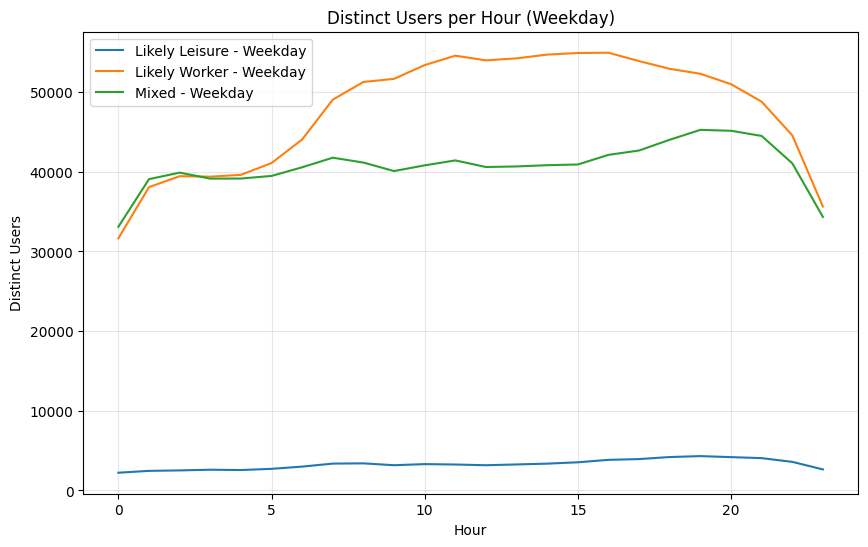

In [142]:
plt.figure(figsize=(10,6))

for vtype in hour_presence["visitor_type"].unique():
    subset = hour_presence[
        (hour_presence["visitor_type"] == vtype) &
        (hour_presence["is_weekend"] == False)
    ]
    plt.plot(subset["hour"], subset["unique_users"], label=f"{vtype} - Weekday")

plt.title("Distinct Users per Hour (Weekday)")
plt.xlabel("Hour")
plt.ylabel("Distinct Users")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

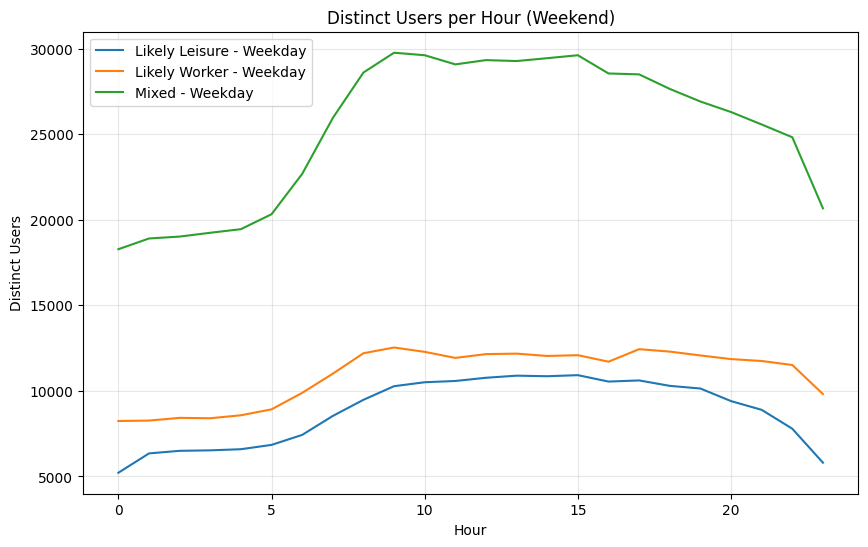

In [143]:
plt.figure(figsize=(10,6))

for vtype in hour_presence["visitor_type"].unique():
    subset = hour_presence[
        (hour_presence["visitor_type"] == vtype) &
        (hour_presence["is_weekend"] == True)
    ]
    plt.plot(subset["hour"], subset["unique_users"], label=f"{vtype} - Weekday")

plt.title("Distinct Users per Hour (Weekend)")
plt.xlabel("Hour")
plt.ylabel("Distinct Users")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [144]:
peak_unique = (
    hour_presence
    .loc[
        hour_presence
        .groupby(["visitor_type", "is_weekend"])["unique_users"]
        .idxmax()
    ]
)

peak_unique

,visitor_type,is_weekend,hour,unique_users
19,Likely Leisure,False,19,4309
39,Likely Leisure,True,15,10921
64,Likely Worker,False,16,54955
81,Likely Worker,True,9,12537
115,Mixed,False,19,45271
129,Mixed,True,9,29773


In [153]:
import geopandas as gpd

LB_shp = gpd.read_file(
    "/green-projects/project-urban_colocation_intelligence/workspace/share/data/boundary/boundary/London_Borough_Excluding_MHW.shp"
)

print(len(LB_shp))
print(LB_shp.columns)

33
Index(['NAME', 'GSS_CODE', 'HECTARES', 'NONLD_AREA', 'ONS_INNER', 'SUB_2009',
       'SUB_2006', 'geometry'],
      dtype='str')


In [155]:
LB_shp

,NAME,GSS_CODE,HECTARES,NONLD_AREA,ONS_INNER,SUB_2009,SUB_2006,geometry
0,Kingston upon Thames,E09000021,3726.117,0.000,F,None,None,"POLYGON ((516401.6 160201.8, 516407.3 160210.5..."
1,Croydon,E09000008,8649.441,0.000,F,None,None,"POLYGON ((535009.2 159504.7, 535005.5 159502, ..."
2,Bromley,E09000006,15013.487,0.000,F,None,None,"POLYGON ((540373.6 157530.4, 540361.2 157551.9..."
3,Hounslow,E09000018,5658.541,60.755,F,None,None,"POLYGON ((521975.8 178100, 521967.7 178096.8, ..."
4,Ealing,E09000009,5554.428,0.000,F,None,None,"POLYGON ((510253.5 182881.6, 510249.9 182886, ..."
5,Havering,E09000016,11445.735,210.763,F,None,None,"POLYGON ((549893.9 181459.8, 549894.6 181465.7..."
6,Hillingdon,E09000017,11570.063,0.000,F,None,None,"POLYGON ((510599.8 191689.5, 510615.2 191591.3..."
7,Harrow,E09000015,5046.330,0.000,F,None,None,"POLYGON ((510599.8 191689.5, 510660 191690.9, ..."
8,Brent,E09000005,4323.270,0.000,F,None,None,"POLYGON ((525201 182512.6, 525181.5 182521.1, ..."
9,Barnet,E09000003,8674.837,0.000,F,None,None,"POLYGON ((524579.9 198355.2, 524594.3 198321.4..."


In [157]:
borough_summary

,lad22nm,total_visitors,origin_cells,visitor_share_%
29,Tower Hamlets,138525,917,31.38
24,Newham,39937,1195,9.05
27,Southwark,30380,1054,6.88
10,Greenwich,21314,1255,4.83
21,Lambeth,19627,1092,4.45
22,Lewisham,18096,1164,4.10
25,Redbridge,13915,1312,3.15
0,Barking and Dagenham,13312,844,3.02
32,Westminster,11963,719,2.71
30,Waltham Forest,10860,999,2.46


In [158]:
LB_shp["NAME"] = LB_shp["NAME"].str.strip()
borough_summary["lad22nm"] = borough_summary["lad22nm"].str.strip()

In [159]:
map_df = LB_shp.merge(
    borough_summary,
    left_on="NAME",
    right_on="lad22nm",
    how="left"
)

map_df["total_visitors"] = map_df["total_visitors"].fillna(0)

In [161]:
map_df = map_df.to_crs(epsg=4326)

In [163]:
scheme="quantiles",
k=5,

In [165]:
import numpy as np

map_df["log_visitors"] = np.log1p(map_df["total_visitors"])

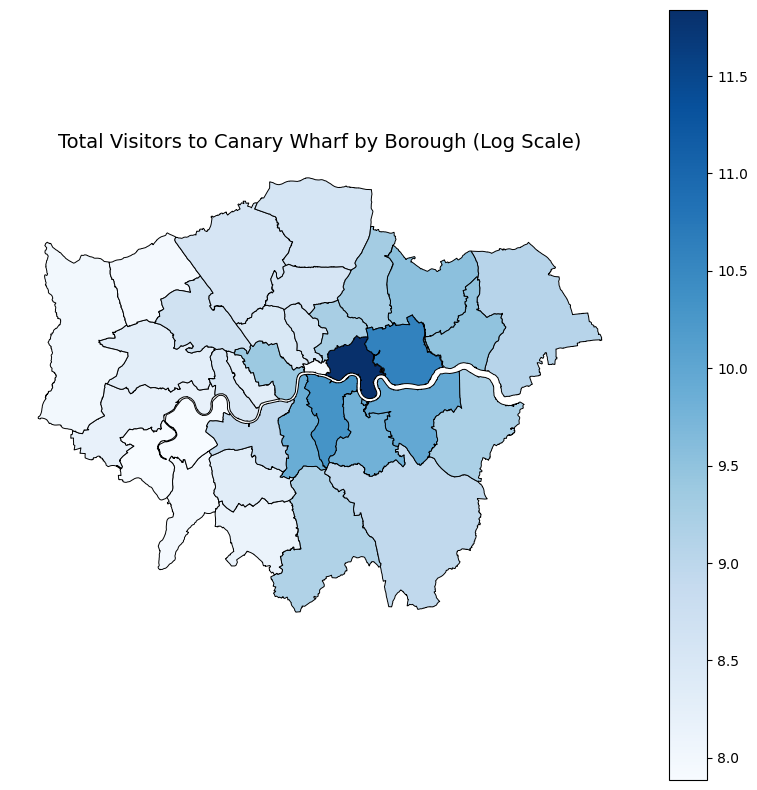

In [166]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))

map_df.plot(
    column="log_visitors",
    cmap="Blues",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Total Visitors to Canary Wharf by Borough (Log Scale)", fontsize=14)
ax.axis("off")

plt.show()

In [167]:
worker_map = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Likely Worker"
][["lad22nm", "percentage"]].copy()

worker_map["lad22nm"] = worker_map["lad22nm"].str.strip()
LB_shp["NAME"] = LB_shp["NAME"].str.strip()

worker_map_df = LB_shp.merge(
    worker_map,
    left_on="NAME",
    right_on="lad22nm",
    how="left"
)

worker_map_df["percentage"] = worker_map_df["percentage"].fillna(0)

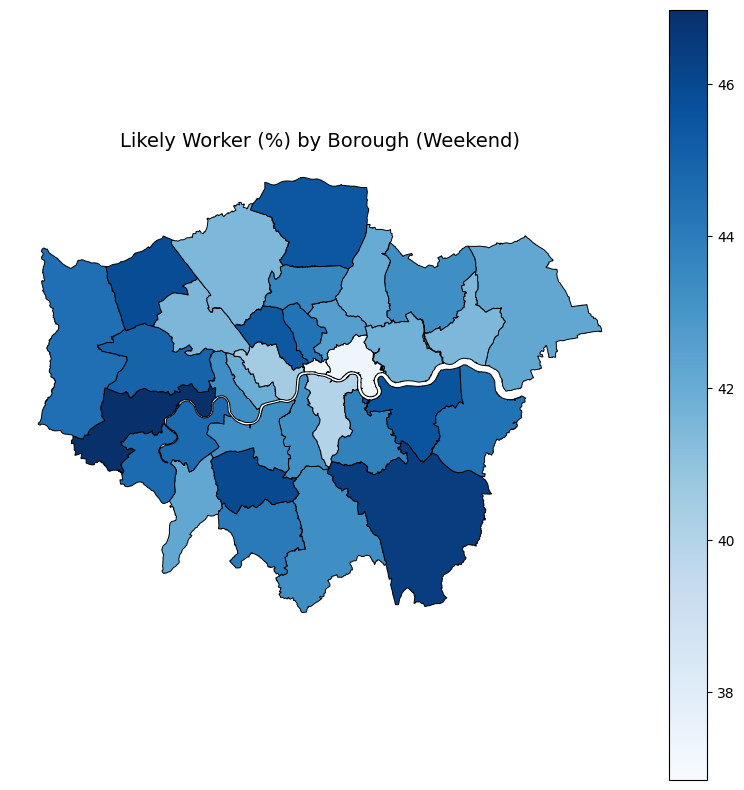

In [168]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,10))

worker_map_df.plot(
    column="percentage",
    cmap="Blues",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Likely Worker (%) by Borough (Weekend)", fontsize=14)
ax.axis("off")

plt.show()

In [169]:
leisure_map = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Likely Leisure"
][["lad22nm", "percentage"]].copy()

leisure_map["lad22nm"] = leisure_map["lad22nm"].str.strip()

leisure_map_df = LB_shp.merge(
    leisure_map,
    left_on="NAME",
    right_on="lad22nm",
    how="left"
)

leisure_map_df["percentage"] = leisure_map_df["percentage"].fillna(0)

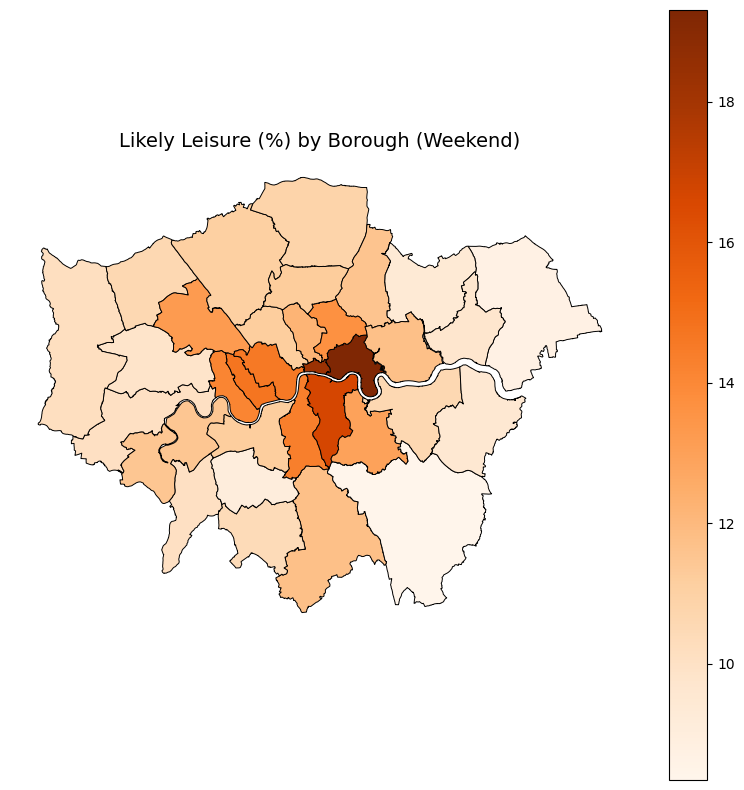

In [170]:
fig, ax = plt.subplots(1, 1, figsize=(10,10))

leisure_map_df.plot(
    column="percentage",
    cmap="Oranges",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Likely Leisure (%) by Borough (Weekend)", fontsize=14)
ax.axis("off")

plt.show()

***INTERACTIVE MAP***

In [171]:
import pandas as pd

worker_df = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Likely Worker"
][["lad22nm", "count", "percentage"]].rename(
    columns={"count": "worker_count",
             "percentage": "worker_pct"}
)

leisure_df = borough_weekend_summary[
    borough_weekend_summary["visitor_type"] == "Likely Leisure"
][["lad22nm", "count", "percentage"]].rename(
    columns={"count": "leisure_count",
             "percentage": "leisure_pct"}
)

combined_df = worker_df.merge(leisure_df, on="lad22nm")

In [172]:
LB_shp = LB_shp.to_crs(epsg=4326)

map_df = LB_shp.merge(
    combined_df,
    left_on="NAME",
    right_on="lad22nm",
    how="left"
)

map_df.fillna(0, inplace=True)

,NAME,GSS_CODE,HECTARES,NONLD_AREA,ONS_INNER,SUB_2009,SUB_2006,geometry,lad22nm,worker_count,worker_pct,leisure_count,leisure_pct
0,Kingston upon Thames,E09000021,3726.117,0.000,F,0,0,"POLYGON ((-0.33068 51.32901, -0.33059 51.32909...",Kingston upon Thames,1201,42.214411,287,10.087873
1,Croydon,E09000008,8649.441,0.000,F,0,0,"POLYGON ((-0.06402 51.31864, -0.06408 51.31861...",Croydon,4083,43.293394,1107,11.737886
2,Bromley,E09000006,15013.487,0.000,F,0,0,"POLYGON ((0.01213 51.2996, 0.01196 51.2998, 0....",Bromley,3545,46.436992,637,8.344249
3,Hounslow,E09000018,5658.541,60.755,F,0,0,"POLYGON ((-0.24456 51.4887, -0.24468 51.48868,...",Hounslow,1692,46.973903,363,10.077735
4,Ealing,E09000009,5554.428,0.000,F,0,0,"POLYGON ((-0.41183 51.53408, -0.41188 51.53412...",Ealing,1761,44.969356,387,9.882533
5,Havering,E09000016,11445.735,210.763,F,0,0,"POLYGON ((0.15869 51.51219, 0.15871 51.51224, ...",Havering,3632,42.217831,751,8.729513
6,Hillingdon,E09000017,11570.063,0.000,F,0,0,"POLYGON ((-0.40407 51.61318, -0.40388 51.61229...",Hillingdon,1317,44.493243,301,10.168919
7,Harrow,E09000015,5046.330,0.000,F,0,0,"POLYGON ((-0.40407 51.61318, -0.4032 51.61318,...",Harrow,1300,45.887752,300,10.589481
8,Brent,E09000005,4323.270,0.000,F,0,0,"POLYGON ((-0.19657 51.52765, -0.19685 51.52773...",Brent,2389,41.482896,762,13.231464
9,Barnet,E09000003,8674.837,0.000,F,0,0,"POLYGON ((-0.1999 51.67017, -0.1997 51.66986, ...",Barnet,2173,41.461553,582,11.104751


In [179]:
map_df = map_df.to_crs(epsg=4326)

map_df.to_file(
    "/green-projects/project-urban_colocation_intelligence/workspace/share/data/cw_weekend_behavior.geojson",
    driver="GeoJSON"
)

**map viz**

In [184]:
visitor_with_borough.head()

,id,weekend_ratio,avg_hour,total_visits,visitor_type,home_h3,lad22nm
0,00001a23cd419bedb93213a0889d04ad,0.213287,13.356643,286,Likely Worker,89197277127ffff,NaN
1,0000a04fe12336da3d1b3478eba428fd,0.000000,11.416667,12,Likely Worker,89194e6d087ffff,Greenwich
2,0000a04fe12336da3d1b3478eba428fd,0.000000,11.416667,12,Likely Worker,89194e6d087ffff,Greenwich
3,0000a04fe12336da3d1b3478eba428fd,0.000000,11.416667,12,Likely Worker,89194e6d087ffff,Greenwich
4,0000a2b6c7f88ae0bcd323a6ea4a4725,0.496350,10.817518,137,Mixed,8919424c51bffff,NaN


In [186]:
visitor_with_borough.columns

Index(['id', 'weekend_ratio', 'avg_hour', 'total_visits', 'visitor_type',
       'home_h3', 'lad22nm'],
      dtype='str')

In [187]:
visitor_with_borough["visitor_type"].unique()

<ArrowStringArray>
['Likely Worker', 'Mixed', 'Likely Leisure']
Length: 3, dtype: str

In [188]:
worker_users = visitor_with_borough[
    visitor_with_borough["visitor_type"] == "Likely Worker"
]

leisure_users = visitor_with_borough[
    visitor_with_borough["visitor_type"] == "Likely Leisure"
]

mixed_users = visitor_with_borough[
    visitor_with_borough["visitor_type"] == "Mixed"
]

In [189]:
worker_counts = (
    worker_users.groupby("home_h3")
    .size()
    .reset_index(name="worker_count")
)

leisure_counts = (
    leisure_users.groupby("home_h3")
    .size()
    .reset_index(name="leisure_count")
)

mixed_counts = (
    mixed_users.groupby("home_h3")
    .size()
    .reset_index(name="mixed_count")
)

In [190]:
worker_counts["geometry"] = worker_counts["home_h3"].apply(h3_to_polygon)
leisure_counts["geometry"] = leisure_counts["home_h3"].apply(h3_to_polygon)
mixed_counts["geometry"] = mixed_counts["home_h3"].apply(h3_to_polygon)

worker_origin_gdf = gpd.GeoDataFrame(worker_counts, geometry="geometry", crs="EPSG:4326")
leisure_origin_gdf = gpd.GeoDataFrame(leisure_counts, geometry="geometry", crs="EPSG:4326")
mixed_origin_gdf = gpd.GeoDataFrame(mixed_counts, geometry="geometry", crs="EPSG:4326")

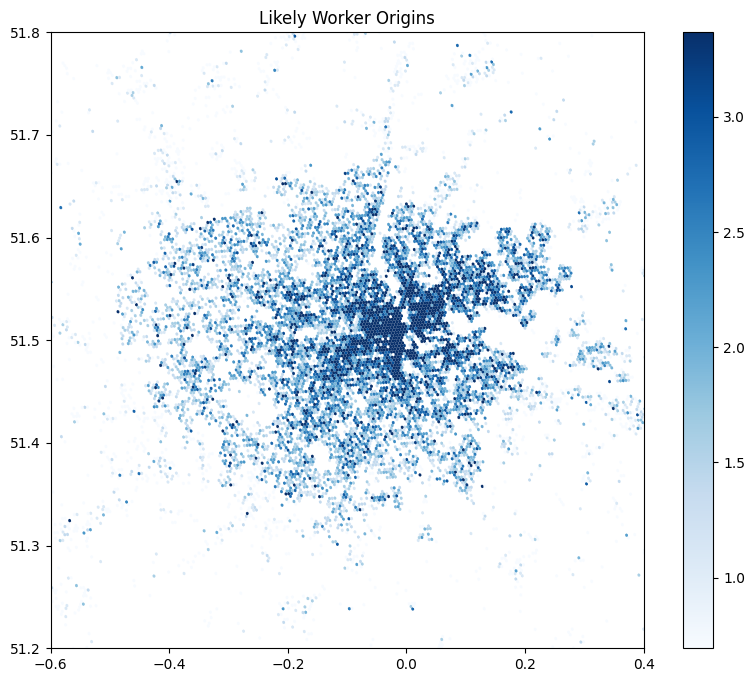

In [194]:
worker_origin_gdf["log_workers"] = np.log1p(worker_origin_gdf["worker_count"])

vmin_w = worker_origin_gdf["log_workers"].quantile(0.05)
vmax_w = worker_origin_gdf["log_workers"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

worker_origin_gdf.plot(
    column="log_workers",
    cmap="Blues",
    legend=True,
    linewidth=0,
    vmin=vmin_w,
    vmax=vmax_w,
    ax=ax
)

ax.set_xlim(-0.6, 0.4)
ax.set_ylim(51.2, 51.8)

plt.title("Likely Worker Origins")
plt.show()

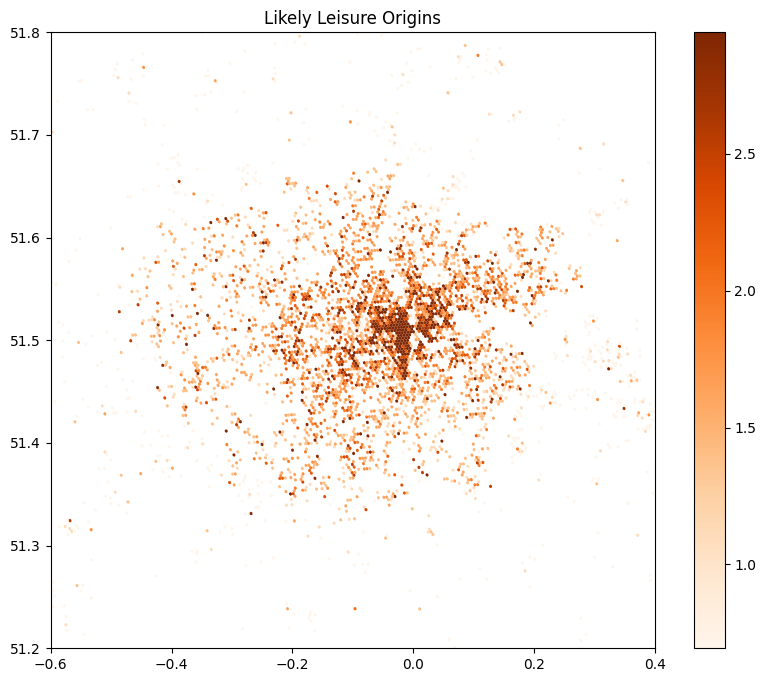

In [195]:
leisure_origin_gdf["log_leisure"] = np.log1p(leisure_origin_gdf["leisure_count"])

vmin_l = leisure_origin_gdf["log_leisure"].quantile(0.05)
vmax_l = leisure_origin_gdf["log_leisure"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

leisure_origin_gdf.plot(
    column="log_leisure",
    cmap="Oranges",
    legend=True,
    linewidth=0,
    vmin=vmin_l,
    vmax=vmax_l,
    ax=ax
)

ax.set_xlim(-0.6, 0.4)
ax.set_ylim(51.2, 51.8)

plt.title("Likely Leisure Origins")
plt.show()

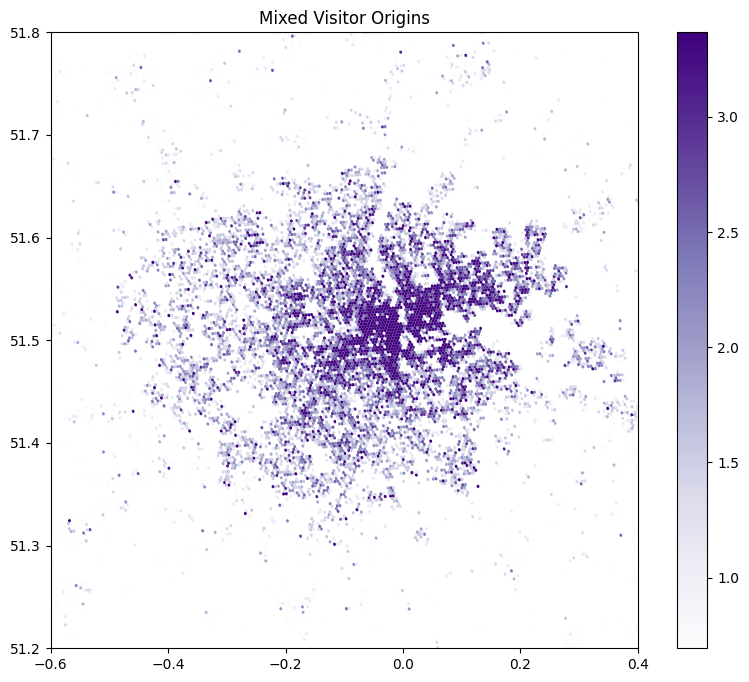

In [196]:
mixed_origin_gdf["log_mixed"] = np.log1p(mixed_origin_gdf["mixed_count"])

vmin_m = mixed_origin_gdf["log_mixed"].quantile(0.05)
vmax_m = mixed_origin_gdf["log_mixed"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

mixed_origin_gdf.plot(
    column="log_mixed",
    cmap="Purples",
    legend=True,
    linewidth=0,
    vmin=vmin_m,
    vmax=vmax_m,
    ax=ax
)

ax.set_xlim(-0.6, 0.4)
ax.set_ylim(51.2, 51.8)

plt.title("Mixed Visitor Origins")
plt.show()

In [197]:
composition = (
    visitor_with_borough
    .groupby("visitor_type")
    .size()
    .reset_index(name="count")
)

In [198]:
total = composition["count"].sum()

composition["percentage"] = (
    composition["count"] / total * 100
).round(2)

composition

,visitor_type,count,percentage
0,Likely Leisure,76966,14.08
1,Likely Worker,226883,41.50
2,Mixed,242838,44.42


In [200]:
borough_rank = (
    visitor_with_borough
    .dropna(subset=["lad22nm"])   # remove NaN boroughs
    .groupby(["visitor_type", "lad22nm"])
    .size()
    .reset_index(name="count")
)

In [201]:
borough_rank["percentage_within_type"] = (
    borough_rank
    .groupby("visitor_type")["count"]
    .transform(lambda x: x / x.sum() * 100)
).round(2)

In [202]:
borough_rank = borough_rank.sort_values(
    ["visitor_type", "count"],
    ascending=[True, False]
)

borough_rank.head(10)

,visitor_type,lad22nm,count,percentage_within_type
29,Likely Leisure,Tower Hamlets,26744,42.16
27,Likely Leisure,Southwark,5066,7.99
24,Likely Leisure,Newham,4696,7.40
21,Likely Leisure,Lambeth,2818,4.44
22,Likely Leisure,Lewisham,2340,3.69
10,Likely Leisure,Greenwich,2262,3.57
32,Likely Leisure,Westminster,1742,2.75
11,Likely Leisure,Hackney,1430,2.25
25,Likely Leisure,Redbridge,1309,2.06
0,Likely Leisure,Barking and Dagenham,1296,2.04


In [204]:
worker_rank = borough_rank[
    borough_rank["visitor_type"] == "Likely Worker"
]

worker_rank.head(10)

,visitor_type,lad22nm,count,percentage_within_type
62,Likely Worker,Tower Hamlets,51659,28.45
57,Likely Worker,Newham,16685,9.19
60,Likely Worker,Southwark,12150,6.69
43,Likely Worker,Greenwich,9714,5.35
54,Likely Worker,Lambeth,8483,4.67
55,Likely Worker,Lewisham,7929,4.37
58,Likely Worker,Redbridge,6021,3.32
33,Likely Worker,Barking and Dagenham,5521,3.04
65,Likely Worker,Westminster,4848,2.67
63,Likely Worker,Waltham Forest,4568,2.52


In [205]:
mixed_rank = borough_rank[
    borough_rank["visitor_type"] == "Mixed"
]

mixed_rank.head(10)

,visitor_type,lad22nm,count,percentage_within_type
95,Mixed,Tower Hamlets,60122,30.60
90,Mixed,Newham,18556,9.45
93,Mixed,Southwark,13164,6.70
76,Mixed,Greenwich,9338,4.75
87,Mixed,Lambeth,8326,4.24
88,Mixed,Lewisham,7827,3.98
91,Mixed,Redbridge,6585,3.35
66,Mixed,Barking and Dagenham,6495,3.31
98,Mixed,Westminster,5373,2.73
96,Mixed,Waltham Forest,5037,2.56


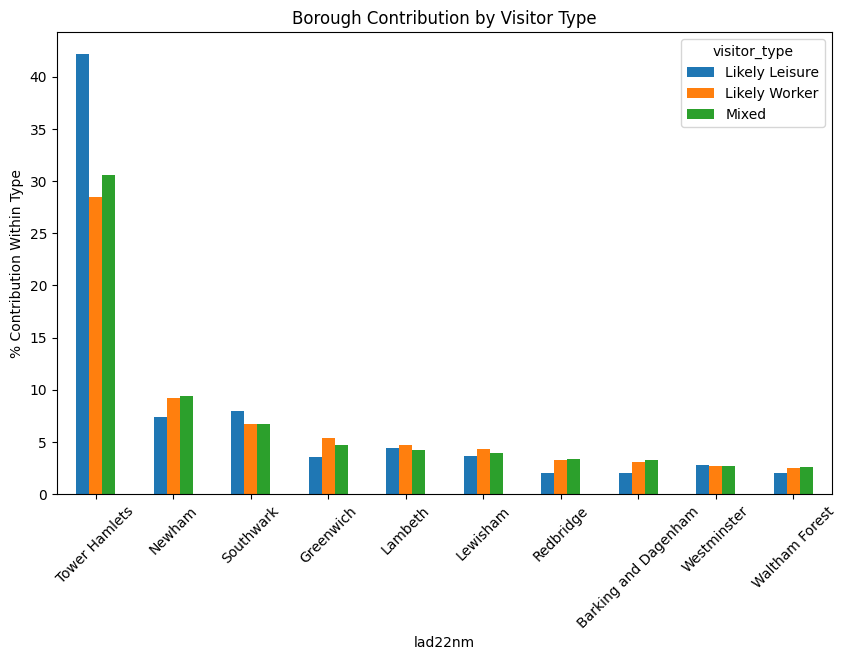

In [208]:
pivot_rank = borough_rank.pivot(
    index="lad22nm",
    columns="visitor_type",
    values="percentage_within_type"
)

pivot_rank = pivot_rank.fillna(0)
pivot_rank = pivot_rank.sort_values("Likely Worker", ascending=False)

pivot_rank.head(10).plot(kind="bar", figsize=(10,6))
plt.ylabel("% Contribution Within Type")
plt.title("Borough Contribution by Visitor Type")
plt.xticks(rotation=45)
plt.show()

In [211]:
top10 = (
    borough_rank
    .sort_values(["visitor_type", "count"], ascending=[True, False])
    .groupby("visitor_type")
    .head(10)
)

top10

,visitor_type,lad22nm,count,percentage_within_type
29,Likely Leisure,Tower Hamlets,26744,42.16
27,Likely Leisure,Southwark,5066,7.99
24,Likely Leisure,Newham,4696,7.40
21,Likely Leisure,Lambeth,2818,4.44
22,Likely Leisure,Lewisham,2340,3.69
10,Likely Leisure,Greenwich,2262,3.57
32,Likely Leisure,Westminster,1742,2.75
11,Likely Leisure,Hackney,1430,2.25
25,Likely Leisure,Redbridge,1309,2.06
0,Likely Leisure,Barking and Dagenham,1296,2.04


**distance**

In [218]:
visitor_with_borough["home_h3"] = (
    visitor_with_borough["home_h3"]
    .astype(str)
)

In [221]:
visitor_with_borough["home_h3"].dtype
visitor_with_borough["home_h3"].head(10)

0    89197277127ffff
1    89194e6d087ffff
2    89194e6d087ffff
3    89194e6d087ffff
4    8919424c51bffff
5    89194ad2667ffff
6    89194ad2667ffff
7    89194ad2667ffff
8    89194e6dc2fffff
9    89194e6dc2fffff
Name: home_h3, dtype: str

In [222]:
import h3

invalid_cells = visitor_with_borough[
    ~visitor_with_borough["home_h3"].apply(lambda x: h3.is_valid_cell(str(x)))
]

invalid_cells.head()

,id,weekend_ratio,avg_hour,total_visits,visitor_type,home_h3,lad22nm
15,0002b6150abc2027e829097bb4491bf0,0.100000,14.950000,20,Likely Worker,NaN,NaN
19,0002efdf45a866648ce73b58a6b37f67,1.000000,13.285714,14,Likely Leisure,NaN,NaN
67,00070c4cd728f89acee064e8baa8e655,0.000000,12.444444,9,Likely Worker,NaN,NaN
72,00080461fc4b9f9740893a9d2382c59c,0.200000,16.000000,5,Likely Worker,NaN,NaN
76,0008e5e557f3280b33b4fb063ae68e23,0.207101,11.076923,338,Likely Worker,NaN,NaN


In [224]:
len(invalid_cells)

45715

In [225]:
visitor_with_borough = visitor_with_borough.dropna(subset=["home_h3"])

In [226]:
visitor_with_borough["home_h3"].isna().sum()

np.int64(0)

In [227]:
from shapely.geometry import Point
import h3

def h3_to_point(h):
    lat, lon = h3.cell_to_latlng(str(h))
    return Point(lon, lat)

visitor_with_borough["geometry"] = (
    visitor_with_borough["home_h3"]
    .apply(h3_to_point)
)

In [228]:
origin_points = gpd.GeoDataFrame(
    visitor_with_borough,
    geometry="geometry",
    crs="EPSG:4326"
)

origin_points = origin_points.to_crs(epsg=27700)

cw_point = gpd.GeoSeries(
    [Point(-0.0235, 51.5054)],
    crs="EPSG:4326"
).to_crs(epsg=27700)

origin_points["distance_km"] = (
    origin_points.geometry.distance(cw_point.iloc[0]) / 1000
)

In [229]:
distance_summary = (
    origin_points
    .groupby("visitor_type")["distance_km"]
    .agg(
        median="median",
        mean="mean",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90)
    )
    .round(2)
)

distance_summary

,median,mean,p75,p90
visitor_type,,,,
Likely Leisure,4.87,18.61,11.15,23.63
Likely Worker,7.04,22.07,13.90,31.61
Mixed,6.97,22.90,14.18,40.25


**mixed map**

In [230]:
from shapely.geometry import Point
import geopandas as gpd

# Canary Wharf center
cw_point = gpd.GeoSeries(
    [Point(-0.0235, 51.5054)],
    crs="EPSG:4326"
)

# Convert to projected CRS
cw_point = cw_point.to_crs(epsg=27700)

# Create 500m buffer for visibility
cw_buffer = cw_point.buffer(500)

In [231]:
LB_shp = LB_shp.to_crs(epsg=27700)

worker_origin_gdf = worker_origin_gdf.to_crs(epsg=27700)
leisure_origin_gdf = leisure_origin_gdf.to_crs(epsg=27700)
mixed_origin_gdf = mixed_origin_gdf.to_crs(epsg=27700)

In [232]:
xmin, ymin, xmax, ymax = LB_shp.total_bounds

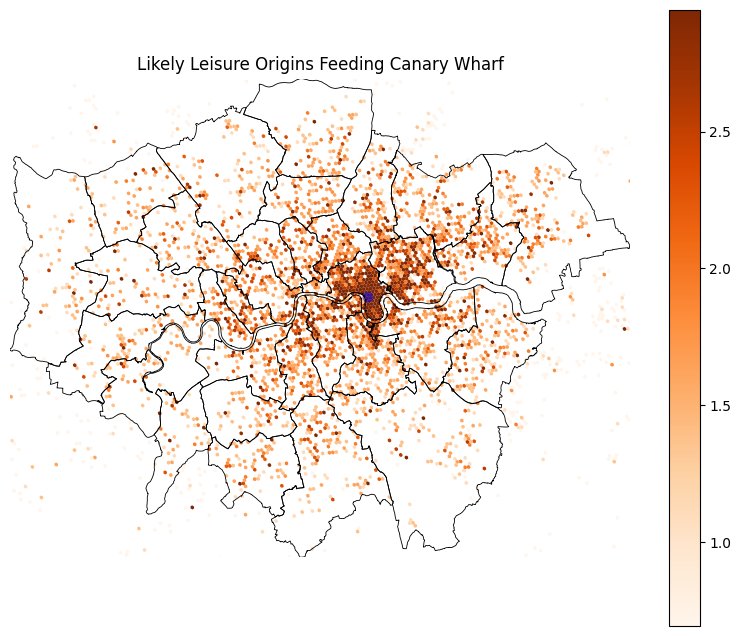

In [233]:
import matplotlib.pyplot as plt
import numpy as np

leisure_origin_gdf["log_val"] = np.log1p(leisure_origin_gdf["leisure_count"])

vmin = leisure_origin_gdf["log_val"].quantile(0.05)
vmax = leisure_origin_gdf["log_val"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot borough outlines
LB_shp.boundary.plot(ax=ax, color="black", linewidth=0.6)

# Plot origin intensity
leisure_origin_gdf.plot(
    column="log_val",
    cmap="Oranges",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    ax=ax
)

# Highlight Canary Wharf
gpd.GeoSeries(cw_buffer).plot(ax=ax, color="blue", alpha=0.5)

ax.set_title("Likely Leisure Origins Feeding Canary Wharf")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")

plt.show()

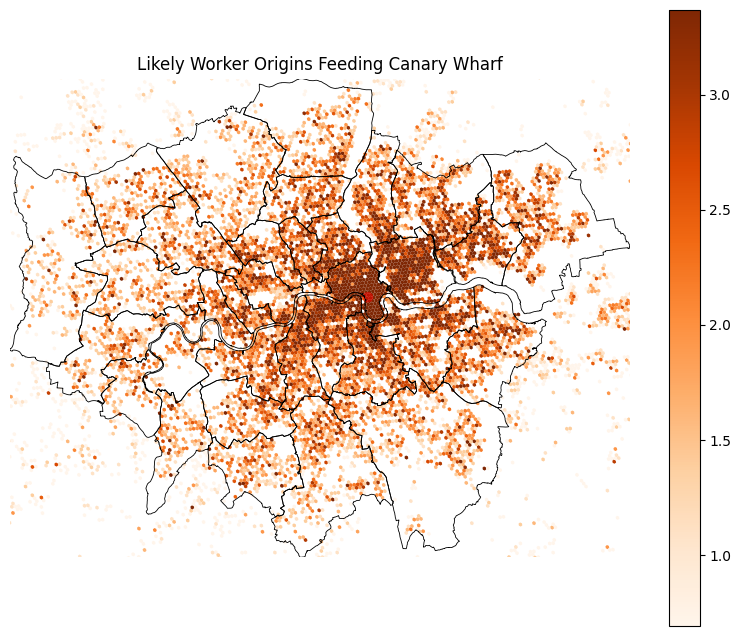

In [238]:
worker_origin_gdf["log_val"] = np.log1p(worker_origin_gdf["worker_count"])

vmin = worker_origin_gdf["log_val"].quantile(0.05)
vmax = worker_origin_gdf["log_val"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

LB_shp.boundary.plot(ax=ax, color="black", linewidth=0.6)

worker_origin_gdf.plot(
    column="log_val",
    cmap="Oranges",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    ax=ax
)

gpd.GeoSeries(cw_buffer).plot(ax=ax, color="red", alpha=0.5)

ax.set_title("Likely Worker Origins Feeding Canary Wharf")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")

plt.show()

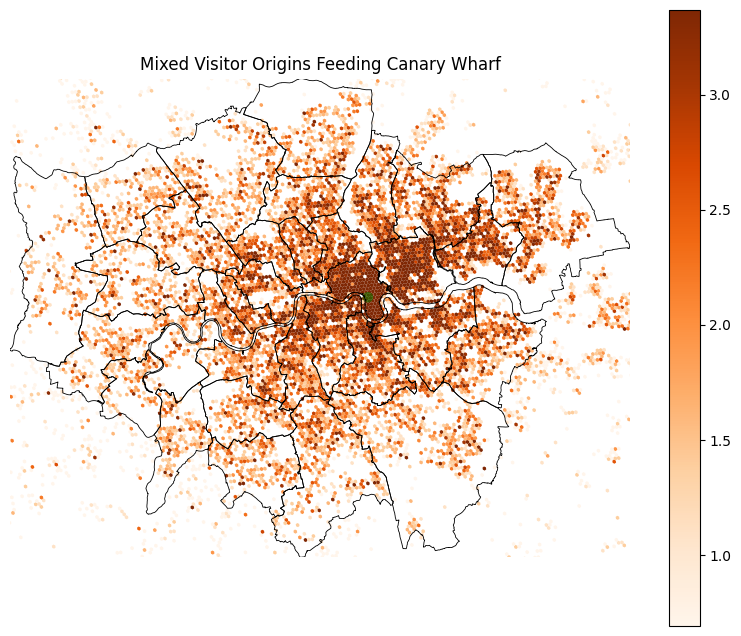

In [239]:
mixed_origin_gdf["log_val"] = np.log1p(mixed_origin_gdf["mixed_count"])

vmin = mixed_origin_gdf["log_val"].quantile(0.05)
vmax = mixed_origin_gdf["log_val"].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 8))

LB_shp.boundary.plot(ax=ax, color="black", linewidth=0.6)

mixed_origin_gdf.plot(
    column="log_val",
    cmap="Oranges",
    vmin=vmin,
    vmax=vmax,
    legend=True,
    ax=ax
)

gpd.GeoSeries(cw_buffer).plot(ax=ax, color="green", alpha=0.5)

ax.set_title("Mixed Visitor Origins Feeding Canary Wharf")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.axis("off")

plt.show()

In [240]:
dup_check = (
    visitor_with_borough
    .groupby("id")["visitor_type"]
    .nunique()
    .reset_index(name="type_count")
)

dup_check["type_count"].value_counts()

type_count
1    185049
Name: count, dtype: int64

# repititive pattern